<a href="https://colab.research.google.com/github/AndreiAf02/Data-Balancing-in-ML-DNN/blob/main/CIFAR10_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CIFAR-10 Dataset - Image Classification using Fine-tuning TL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter



from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
# !pip install pytorch-tabnet

# from pytorch_tabnet.tab_model import TabNetClassifier
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from keras.datasets import mnist, fashion_mnist, cifar10


## Collecting the CIFAR-10 Data:

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [3]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

[4]


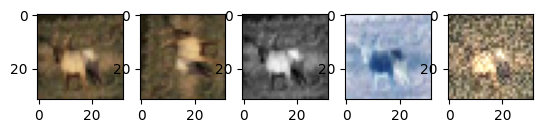

In [4]:
i = 3

print(train_labels[i])

figure_for_plotting = train_images[i] #.transpose((1, 0, 2))
plt.subplot(1, 5, 1)
plt.imshow(figure_for_plotting)

plt.subplot(1, 5, 2)
plt.imshow(figure_for_plotting.transpose((1, 0, 2)))

# np.clip(noisy_figure, 0, 255)
gs_figure_for_plotting = np.mean(train_images[i],axis=2)
plt.subplot(1, 5, 3)
plt.imshow(gs_figure_for_plotting, cmap='gray')


plt.subplot(1, 5, 4)
plt.imshow(-figure_for_plotting)


noisy_figure = figure_for_plotting + np.random.randint(0,100,size=(figure_for_plotting.shape[0], figure_for_plotting.shape[1], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)

plt.subplot(1, 5, 5)
plt.imshow(noisy_figure)

## Creating the Imbalanced Source training set using Data Augmentation (Deer vs Dogs):

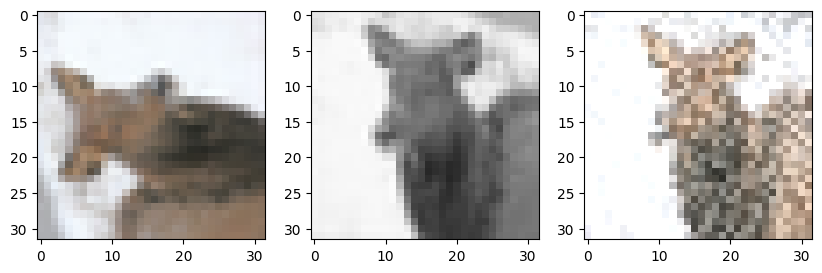

In [5]:
maj_label=4
min_label=5

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

# train_binary_maj = train_binary_label1

orig_maj_len = len(train_binary_label1)

# train_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = train_binary_label1.transpose((0, 2, 1, 3))
# train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
train_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - train_binary_label1
# train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = train_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = train_binary_label1 + np.random.randint(0,max_noise,size=(train_binary_label1.shape[0], train_binary_label1.shape[1], train_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)


# print(train_binary_maj)


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 3, 1)
plt.imshow(train_binary_maj[orig_maj_len-1])

plt.subplot(1, 3, 2)
plt.imshow(train_binary_maj[2*orig_maj_len-1])

# plt.subplot(1, 5, 3)
# plt.imshow(train_binary_maj[3*orig_maj_len-1])

plt.subplot(1, 3, 3)
plt.imshow(train_binary_maj[3*orig_maj_len-1])

# plt.subplot(1, 4, 4)
# plt.imshow(train_binary_maj[4*orig_maj_len-1])

np.random.seed(333)
np.random.shuffle(train_binary_maj)



Text(0.5, 1.0, 'Original Figure')

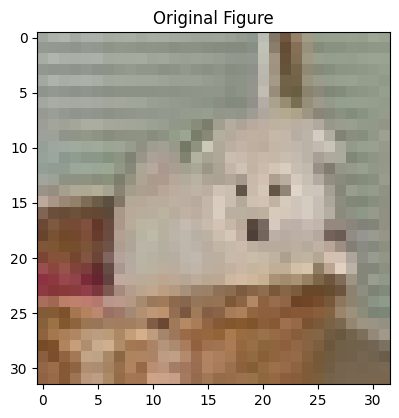

In [6]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]


train_binary_min = train_binary_label2

# noisy_figure = train_binary_label2 + np.random.randint(0,max_noise,size=(train_binary_label2.shape[0], train_binary_label2.shape[1], train_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(train_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(train_binary_min[-1])
# plt.title('Noisy Figure')

In [7]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(15000, 32, 32, 3)
(5000, 32, 32, 3)


,count
0,15000
1,5000


In [8]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
19995,0.760784,0.768627,0.784314,0.705882,0.705882,0.721569,0.698039,0.698039,0.713726,0.776471,...,0.745098,0.694118,0.662745,0.752941,0.701961,0.666667,0.756863,0.705882,0.674510,1
19996,0.733333,0.725490,0.717647,0.768627,0.784314,0.784314,0.764706,0.772549,0.772549,0.776471,...,0.317647,0.309804,0.317647,0.298039,0.290196,0.301961,0.392157,0.384314,0.396078,1
19997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.003922,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
19998,0.431373,0.450980,0.427451,0.352941,0.478431,0.407843,0.321569,0.458824,0.372549,0.345098,...,0.184314,0.360784,0.286275,0.152941,0.317647,0.254902,0.262745,0.360784,0.317647,1
19999,0.631373,0.650980,0.623529,0.674510,0.694118,0.666667,0.690196,0.709804,0.682353,0.643137,...,0.470588,0.400000,0.309804,0.474510,0.400000,0.305882,0.478431,0.400000,0.305882,1


## Creating the Imbalanced Source testing set using Data Augmentation:

3000


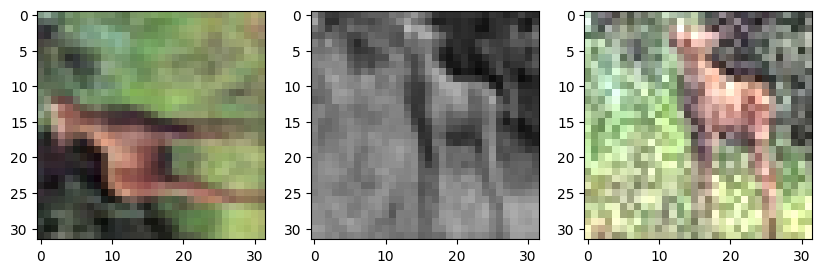

In [9]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

# test_binary_maj = test_binary_label1

orig_maj_len = len(test_binary_label1)

# test_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = test_binary_label1.transpose((0, 2, 1, 3))
# test_binary_maj = np.append(test_binary_maj, maj_transpose, axis=0)
test_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - test_binary_label1
# test_binary_maj = np.append(test_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = test_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = test_binary_label1 + np.random.randint(0,max_noise,size=(test_binary_label1.shape[0], test_binary_label1.shape[1], test_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)

print(len(test_binary_maj))


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 3, 1)
plt.imshow(test_binary_maj[orig_maj_len-1])

plt.subplot(1, 3, 2)
plt.imshow(test_binary_maj[2*orig_maj_len-1])

# plt.subplot(1, 5, 3)
# plt.imshow(test_binary_maj[3*orig_maj_len-1])
# plt.title('Negative')

plt.subplot(1, 3, 3)
plt.imshow(test_binary_maj[3*orig_maj_len-1])

# plt.subplot(1, 4, 4)
# plt.imshow(test_binary_maj[4])


np.random.seed(333)
np.random.shuffle(test_binary_maj)



Text(0.5, 1.0, 'Original Figure')

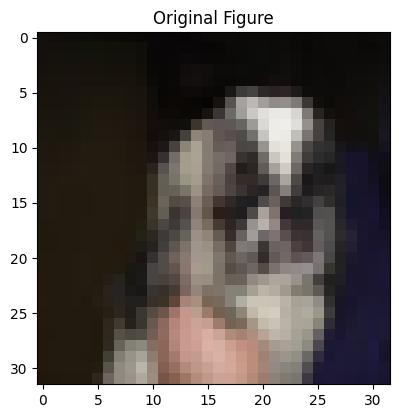

In [10]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

test_binary_min = test_binary_label2

# noisy_figure = test_binary_label2 + np.random.randint(0,max_noise,size=(test_binary_label2.shape[0], test_binary_label2.shape[1], test_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# test_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(test_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(test_binary_min[-1])
# plt.title('Noisy Figure')

In [11]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(3000, 32, 32, 3)
(1000, 32, 32, 3)


,count
0,3000
1,1000


In [12]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
3995,0.545098,0.521569,0.262745,0.603922,0.576471,0.329412,0.776471,0.784314,0.647059,0.768627,...,0.709804,0.749020,0.600000,0.670588,0.694118,0.545098,0.623529,0.639216,0.498039,1
3996,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,...,0.388235,0.219608,0.188235,0.364706,0.188235,0.152941,0.341176,0.164706,0.133333,1
3997,0.325490,0.372549,0.356863,0.262745,0.349020,0.415686,0.364706,0.407843,0.419608,0.576471,...,0.345098,0.384314,0.384314,0.286275,0.337255,0.345098,0.298039,0.368627,0.376471,1
3998,0.372549,0.384314,0.360784,0.364706,0.360784,0.352941,0.376471,0.349020,0.360784,0.360784,...,0.227451,0.219608,0.243137,0.207843,0.200000,0.223529,0.211765,0.203922,0.227451,1
3999,0.078431,0.058824,0.047059,0.074510,0.054902,0.043137,0.058824,0.054902,0.043137,0.058824,...,0.094118,0.090196,0.196078,0.101961,0.090196,0.207843,0.098039,0.078431,0.184314,1


In [13]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data_source = pd.concat([train_binary_flattened, test_binary_flattened])

data_source.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
3995,0.545098,0.521569,0.262745,0.603922,0.576471,0.329412,0.776471,0.784314,0.647059,0.768627,...,0.749020,0.600000,0.670588,0.694118,0.545098,0.623529,0.639216,0.498039,1,1
3996,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,...,0.219608,0.188235,0.364706,0.188235,0.152941,0.341176,0.164706,0.133333,1,1
3997,0.325490,0.372549,0.356863,0.262745,0.349020,0.415686,0.364706,0.407843,0.419608,0.576471,...,0.384314,0.384314,0.286275,0.337255,0.345098,0.298039,0.368627,0.376471,1,1
3998,0.372549,0.384314,0.360784,0.364706,0.360784,0.352941,0.376471,0.349020,0.360784,0.360784,...,0.219608,0.243137,0.207843,0.200000,0.223529,0.211765,0.203922,0.227451,1,1
3999,0.078431,0.058824,0.047059,0.074510,0.054902,0.043137,0.058824,0.054902,0.043137,0.058824,...,0.090196,0.196078,0.101961,0.090196,0.207843,0.098039,0.078431,0.184314,1,1


In [14]:
data_source['Y'].value_counts()

,count
Y,
0,18000
1,6000


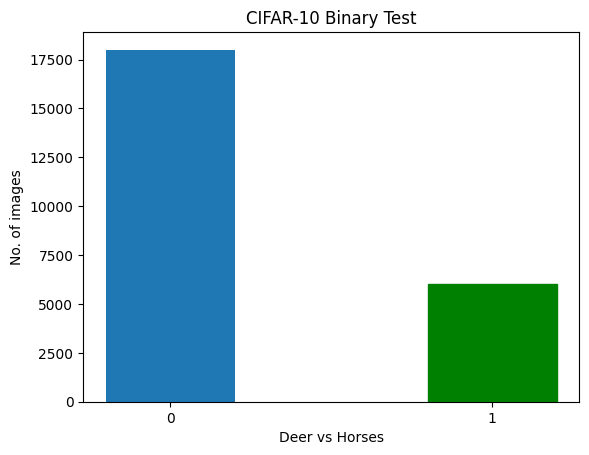

In [15]:
barlist = plt.bar([str(0),str(1)], data_source['Y'].value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Horses")
plt.ylabel("No. of images")
plt.title("CIFAR-10 Binary Test")
plt.show()

## Creating the Imbalanced Target training set using Data Augmentation (Cats vs Dogs):

5000


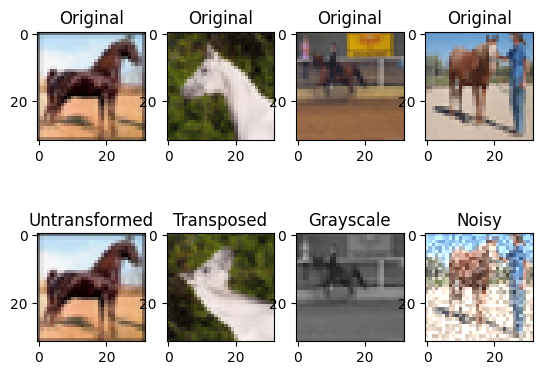

In [16]:
maj_label=7
min_label=3

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

# train_binary_maj = train_binary_label1
# plt.imshow(train_binary_maj[-2])

# # train_binary_maj = train_binary_label1




orig_maj_len = int(len(train_binary_label1)/4)

train_binary_maj = train_binary_label1[:orig_maj_len]

# train_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = train_binary_label1[orig_maj_len:2*orig_maj_len].transpose((0, 2, 1, 3))
train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
# train_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - train_binary_label1
# train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = train_binary_label1[2*orig_maj_len:3*orig_maj_len].mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = (train_binary_label1[3*orig_maj_len:4*orig_maj_len]
                + np.random.randint(0,max_noise,size=(train_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[0],
                                            train_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[1],
                                            train_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[2], 1)))
noisy_figure = np.clip(noisy_figure, 0, 255)
train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)


print(len(train_binary_maj))


plt.subplot(2, 4, 1)
plt.imshow(train_binary_label1[orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 2)
plt.imshow(train_binary_label1[2*orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 3)
plt.imshow(train_binary_label1[3*orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 4)
plt.imshow(train_binary_label1[4*orig_maj_len-1])
plt.title('Original')

## Plotting the augmented figures:

plt.subplot(2, 4, 5)
plt.imshow(train_binary_maj[orig_maj_len-1])
plt.title('Untransformed')

plt.subplot(2, 4, 6)
plt.imshow(train_binary_maj[2*orig_maj_len-1])
plt.title('Transposed')

plt.subplot(2, 4, 7)
plt.imshow(train_binary_maj[3*orig_maj_len-1])
plt.title('Grayscale')

plt.subplot(2, 4, 8)
plt.imshow(train_binary_maj[4*orig_maj_len-1])
plt.title('Noisy')



np.random.seed(333)
np.random.shuffle(train_binary_maj)


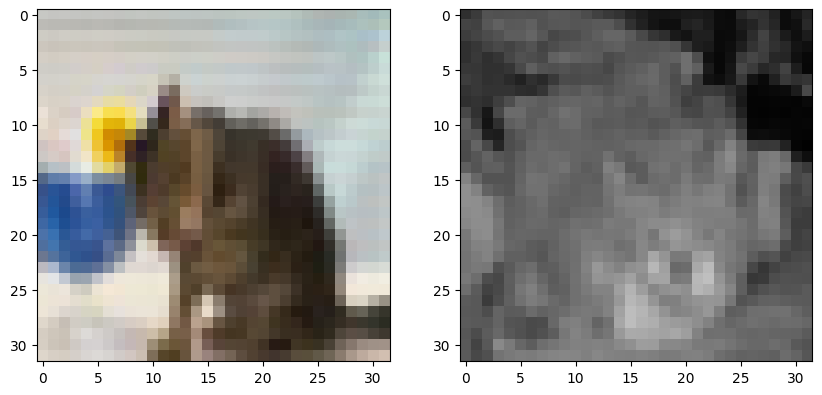

In [17]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]

# np.random.seed(333)
# sampled_min_index = np.random.choice(train_binary_label2.shape[0], size= int(len(train_binary_label2)/4), replace=False)
# train_binary_min = train_binary_label2[sampled_min_index]



np.random.seed(333)
sampled_min_index = np.random.choice(train_binary_label2.shape[0], size= int(len(train_binary_label2)/2), replace=False)
min_samples = train_binary_label2[sampled_min_index]

min_train_split = int(len(min_samples)/2)

train_binary_min = min_samples[:min_train_split]


gs_fig = min_samples[min_train_split:].mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_min = np.append(train_binary_min, gs_fig, axis=0)

np.random.seed(333)
np.random.shuffle(train_binary_min)

plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(train_binary_min[min_train_split-3])

plt.subplot(1, 2, 2)
plt.imshow(train_binary_min[-1])




In [18]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(5000, 32, 32, 3)
(2500, 32, 32, 3)


,count
0,5000
1,2500


In [19]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
7495,0.564706,0.564706,0.564706,0.568627,0.568627,0.568627,0.568627,0.568627,0.568627,0.572549,...,0.800000,0.800000,0.800000,0.376471,0.376471,0.376471,0.164706,0.164706,0.164706,1
7496,0.427451,0.427451,0.427451,0.470588,0.470588,0.470588,0.450980,0.450980,0.450980,0.407843,...,0.380392,0.380392,0.380392,0.368627,0.368627,0.368627,0.349020,0.349020,0.349020,1
7497,0.619608,0.619608,0.619608,0.631373,0.631373,0.631373,0.643137,0.643137,0.643137,0.737255,...,0.478431,0.478431,0.478431,0.447059,0.447059,0.447059,0.423529,0.423529,0.423529,1
7498,0.274510,0.258824,0.258824,0.262745,0.239216,0.262745,0.247059,0.223529,0.235294,0.274510,...,0.725490,0.686275,0.650980,0.729412,0.690196,0.654902,0.752941,0.705882,0.666667,1
7499,0.184314,0.184314,0.184314,0.231373,0.231373,0.231373,0.325490,0.325490,0.325490,0.317647,...,0.423529,0.423529,0.423529,0.392157,0.392157,0.392157,0.337255,0.337255,0.337255,1


## Creating the Imbalanced Target testing set using Data Augmentation:

1000


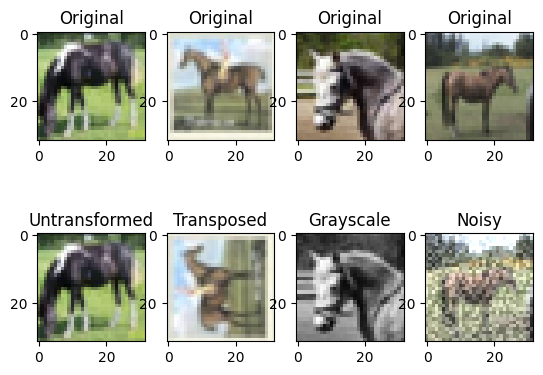

In [20]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

# test_binary_maj = test_binary_label1
# plt.imshow(test_binary_maj[-2])


orig_maj_len = int(len(test_binary_label1)/4)

test_binary_maj = test_binary_label1[:orig_maj_len]

# Incorporating the transposed image:
maj_transpose = test_binary_label1[orig_maj_len:2*orig_maj_len].transpose((0, 2, 1, 3))
test_binary_maj = np.append(test_binary_maj, maj_transpose, axis=0)
# test_binary_maj = maj_transpose


## Incoporating the grayscale image:
gs_fig = test_binary_label1[2*orig_maj_len:3*orig_maj_len].mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = (test_binary_label1[3*orig_maj_len:4*orig_maj_len]
                + np.random.randint(0,max_noise,size=(test_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[0],
                                            test_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[1],
                                            test_binary_label1[3*orig_maj_len:4*orig_maj_len].shape[2], 1)))
noisy_figure = np.clip(noisy_figure, 0, 255)
test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)


print(len(test_binary_maj))


plt.subplot(2, 4, 1)
plt.imshow(test_binary_label1[orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 2)
plt.imshow(test_binary_label1[2*orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 3)
plt.imshow(test_binary_label1[3*orig_maj_len-1])
plt.title('Original')

plt.subplot(2, 4, 4)
plt.imshow(test_binary_label1[4*orig_maj_len-1])
plt.title('Original')

## Plotting the augmented figures:

plt.subplot(2, 4, 5)
plt.imshow(test_binary_maj[orig_maj_len-1])
plt.title('Untransformed')

plt.subplot(2, 4, 6)
plt.imshow(test_binary_maj[2*orig_maj_len-1])
plt.title('Transposed')

plt.subplot(2, 4, 7)
plt.imshow(test_binary_maj[3*orig_maj_len-1])
plt.title('Grayscale')

plt.subplot(2, 4, 8)
plt.imshow(test_binary_maj[4*orig_maj_len-1])
plt.title('Noisy')



np.random.seed(333)
np.random.shuffle(test_binary_maj)



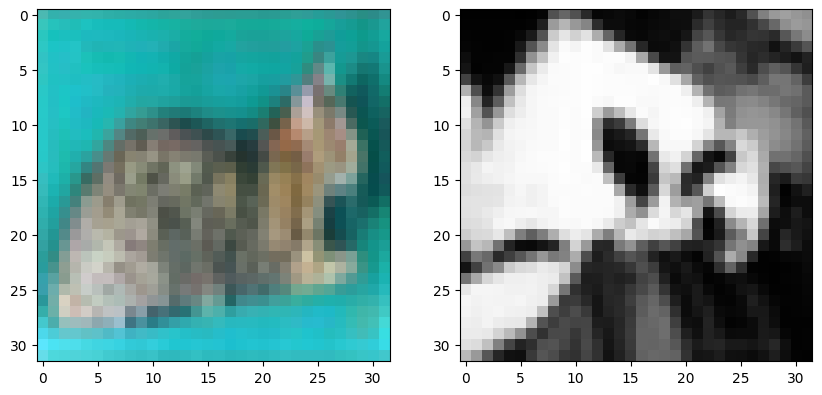

In [21]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

# np.random.seed(333)
# sampled_min_index = np.random.choice(test_binary_label2.shape[0], size= int(len(test_binary_label2)/4), replace=False)
# test_binary_min = test_binary_label2[sampled_min_index]


np.random.seed(333)
sampled_min_index = np.random.choice(test_binary_label2.shape[0], size= int(len(test_binary_label2)/2), replace=False)
min_samples = test_binary_label2[sampled_min_index]

min_test_split = int(len(min_samples)/2)

test_binary_min = min_samples[:min_test_split]


gs_fig = min_samples[min_test_split:].mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_min = np.append(test_binary_min, gs_fig, axis=0)

np.random.seed(333)
np.random.shuffle(test_binary_min)

plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(test_binary_min[min_test_split-1])

plt.subplot(1, 2, 2)
plt.imshow(test_binary_min[-1])



In [22]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(1000, 32, 32, 3)
(500, 32, 32, 3)


,count
0,1000
1,500


In [23]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
1495,0.305882,0.305882,0.305882,0.317647,0.317647,0.317647,0.392157,0.392157,0.392157,0.411765,...,0.337255,0.337255,0.337255,0.266667,0.266667,0.266667,0.188235,0.188235,0.188235,1
1496,0.513726,0.513726,0.513726,0.501961,0.501961,0.501961,0.517647,0.517647,0.517647,0.450980,...,0.921569,0.921569,0.921569,0.921569,0.921569,0.921569,0.909804,0.909804,0.909804,1
1497,0.435294,0.435294,0.435294,0.454902,0.454902,0.454902,0.470588,0.470588,0.470588,0.454902,...,0.447059,0.447059,0.447059,0.372549,0.372549,0.372549,0.360784,0.360784,0.360784,1
1498,0.729412,0.729412,0.729412,0.988235,0.988235,0.988235,0.941176,0.941176,0.941176,0.682353,...,0.192157,0.192157,0.192157,0.227451,0.227451,0.227451,0.243137,0.243137,0.243137,1
1499,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,...,0.050980,0.050980,0.050980,0.011765,0.011765,0.011765,0.007843,0.007843,0.007843,1


In [24]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data_target = pd.concat([train_binary_flattened, test_binary_flattened])

data_target.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
1495,0.305882,0.305882,0.305882,0.317647,0.317647,0.317647,0.392157,0.392157,0.392157,0.411765,...,0.337255,0.337255,0.266667,0.266667,0.266667,0.188235,0.188235,0.188235,1,1
1496,0.513726,0.513726,0.513726,0.501961,0.501961,0.501961,0.517647,0.517647,0.517647,0.450980,...,0.921569,0.921569,0.921569,0.921569,0.921569,0.909804,0.909804,0.909804,1,1
1497,0.435294,0.435294,0.435294,0.454902,0.454902,0.454902,0.470588,0.470588,0.470588,0.454902,...,0.447059,0.447059,0.372549,0.372549,0.372549,0.360784,0.360784,0.360784,1,1
1498,0.729412,0.729412,0.729412,0.988235,0.988235,0.988235,0.941176,0.941176,0.941176,0.682353,...,0.192157,0.192157,0.227451,0.227451,0.227451,0.243137,0.243137,0.243137,1,1
1499,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,0.003922,...,0.050980,0.050980,0.011765,0.011765,0.011765,0.007843,0.007843,0.007843,1,1


In [25]:
data_target['Y'].value_counts()

,count
Y,
0,6000
1,3000


# Splitting for Source and Target Domains:


# Full Dataset:

For the Heart Disease prediction, we split the dataset between low education level (**now including high-school dropouts**) and the high education level. The high-education data (with diabetes as response variable/label) becomes the source data and the low-education data (with Heart Disease as response variable/label) is the target data.

In [26]:
data_source

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
0,0.349020,0.349020,0.349020,0.364706,0.364706,0.364706,0.329412,0.329412,0.329412,0.192157,...,0.729412,0.729412,0.725490,0.725490,0.725490,0.686275,0.686275,0.686275,0,0
1,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.823529,0.823529,0.811765,0.811765,0.811765,0.815686,0.815686,0.815686,0,0
2,0.145098,0.145098,0.117647,0.137255,0.133333,0.109804,0.203922,0.200000,0.188235,0.309804,...,0.133333,0.105882,0.094118,0.082353,0.043137,0.062745,0.062745,0.039216,0,0
3,0.149020,0.149020,0.149020,0.180392,0.180392,0.180392,0.180392,0.180392,0.180392,0.156863,...,0.517647,0.517647,0.525490,0.525490,0.525490,0.525490,0.525490,0.525490,0,0
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.933333,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.545098,0.521569,0.262745,0.603922,0.576471,0.329412,0.776471,0.784314,0.647059,0.768627,...,0.749020,0.600000,0.670588,0.694118,0.545098,0.623529,0.639216,0.498039,1,1
3996,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,...,0.219608,0.188235,0.364706,0.188235,0.152941,0.341176,0.164706,0.133333,1,1
3997,0.325490,0.372549,0.356863,0.262745,0.349020,0.415686,0.364706,0.407843,0.419608,0.576471,...,0.384314,0.384314,0.286275,0.337255,0.345098,0.298039,0.368627,0.376471,1,1
3998,0.372549,0.384314,0.360784,0.364706,0.360784,0.352941,0.376471,0.349020,0.360784,0.360784,...,0.219608,0.243137,0.207843,0.200000,0.223529,0.211765,0.203922,0.227451,1,1


In [27]:
data_target

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
0,0.031373,0.031373,0.031373,0.043137,0.043137,0.043137,0.141176,0.141176,0.141176,0.294118,...,0.054902,0.054902,0.054902,0.054902,0.054902,0.050980,0.050980,0.050980,0,0
1,0.294118,0.270588,0.262745,0.290196,0.258824,0.247059,0.345098,0.294118,0.270588,0.294118,...,0.290196,0.258824,0.494118,0.482353,0.458824,0.603922,0.564706,0.552941,0,0
2,0.003922,0.003922,0.003922,0.023529,0.023529,0.023529,0.160784,0.160784,0.160784,0.101961,...,0.407843,0.407843,0.396078,0.396078,0.396078,0.400000,0.400000,0.400000,0,0
3,0.678431,0.678431,0.678431,0.678431,0.678431,0.678431,0.694118,0.694118,0.694118,0.701961,...,0.317647,0.317647,0.611765,0.611765,0.611765,0.588235,0.588235,0.588235,0,0
4,0.200000,0.372549,0.266667,0.211765,0.376471,0.274510,0.290196,0.447059,0.345098,0.317647,...,0.494118,0.490196,0.360784,0.501961,0.494118,0.352941,0.509804,0.486275,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.305882,0.305882,0.305882,0.317647,0.317647,0.317647,0.392157,0.392157,0.392157,0.411765,...,0.337255,0.337255,0.266667,0.266667,0.266667,0.188235,0.188235,0.188235,1,1
1496,0.513726,0.513726,0.513726,0.501961,0.501961,0.501961,0.517647,0.517647,0.517647,0.450980,...,0.921569,0.921569,0.921569,0.921569,0.921569,0.909804,0.909804,0.909804,1,1
1497,0.435294,0.435294,0.435294,0.454902,0.454902,0.454902,0.470588,0.470588,0.470588,0.454902,...,0.447059,0.447059,0.372549,0.372549,0.372549,0.360784,0.360784,0.360784,1,1
1498,0.729412,0.729412,0.729412,0.988235,0.988235,0.988235,0.941176,0.941176,0.941176,0.682353,...,0.192157,0.192157,0.227451,0.227451,0.227451,0.243137,0.243137,0.243137,1,1


## Transfer Learning Fine-Tuning:

In [28]:
def create_dnn_model(input_shape):
  model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no diabetes)
    ])
  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

  model.summary()
  print(len(model.layers))

  return model

# def create_dnn_model(input_shape):
#   model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
#         layers.Dense(32, activation='relu'),
#         layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no diabetes)
#     ])

#   model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

#   return model



def train_and_evaluate(model, X_train, X_test, y_train, y_test, domain):

    time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)


    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)

    # Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # # Confusion Matrix
    # conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

    model.save('model.h5')
    model.save_weights('model_wt.weights.h5')

    return model


In [29]:
def train_and_evaluate_nosave(model, X_train, X_test, y_train, y_test, domain):

    time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])

    print(fpr)
    print(fnr)

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

    return fpr, fnr


In [30]:
def fine_tuning(X_train, X_test, y_train, y_test, llim, ulim):
    new_model = create_dnn_model(X_S_train.shape[1])
    # new_model = tf.keras.models.load_model('model.h5')
    new_model.load_weights('model_wt.weights.h5')

    for layer in new_model.layers[llim:ulim]:
        layer.trainable = False
    for layer in new_model.layers[-1:]:
        layer.trainable = False

    for layer in new_model.layers:
        if layer.trainable == True:
          print("Trainable")
        else:
          print("Not Trainable")

    fpr, fnr = train_and_evaluate_nosave(new_model, X_train, X_test, y_train, y_test, "Target")
    return fpr, fnr

In [31]:
def Transductive_TL(model, X_test, y_test, domain):

    time_start = perf_counter()

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)
    conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    # # Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # Confusion Matrix
    # print('Confusion matrix:', conf_matrix)
    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)
    conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")
    print('False Negative Rate:', fnr)

    time_stop = perf_counter()

    print('Time elapsed (performance):', time_stop-time_start)

# Over/undersampling functions:

## Undersampling functions:

In [32]:
import random

def SRS_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_maj_rus = data_majority.sample(n=undersample_size, replace=False)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS = data_SRS_RUS.iloc[:, :-1]
    y_SRS = data_SRS_RUS.iloc[:, -1]

    return X_SRS, y_SRS


def SRSwR_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_maj_rus = data_majority.sample(n=undersample_size, replace=True)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS = data_SRS_RUS.iloc[:, :-1]
    y_SRS = data_SRS_RUS.iloc[:, -1]

    return X_SRS, y_SRS


def systematic_undersampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)
    print(undersample_size)
    print(oversample_size)

    k = oversample_size/undersample_size
    print(k)
    np.random.seed(333)
    start = random.randint(1, int(k))
    print(start)
    Row = []
    for i in range(undersample_size):
      row = start+int(k*i)-1
      Row.append(row)
    print(Row)
    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]
    data_maj_rus
    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])

    X_Sy = data_Sy_RUS.iloc[:, :-1]
    y_Sy = data_Sy_RUS.iloc[:, -1]

    return X_Sy, y_Sy



def multi_systematic_undersampler(data, data_column, m):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)
    print(undersample_size)
    print(oversample_size)

    k = oversample_size/undersample_size
    print(k)
    np.random.seed(333)
    start = random.sample(range(1, int(k*m)), m)
    Row = []
    for j in range(len(start)):
      for i in range(int(undersample_size/m)):
        row = start[j]+int(k*i)-1
        Row.append(row)
    print(Row)
    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]
    data_maj_rus
    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])

    X_Sy = data_Sy_RUS.iloc[:, :-1]
    y_Sy = data_Sy_RUS.iloc[:, -1]

    return X_Sy, y_Sy

## Oversampling functions:

In [33]:
def SRSwR_oversampler(data, data_column):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    np.random.seed(333)
    data_min_ros = data_minority.sample(n=oversample_size - undersample_size, replace=True)
    data_SRS_ROS = pd.concat([data_majority, data_minority, data_min_ros])
    X_SRS = data_SRS_ROS.iloc[:, :-1]
    y_SRS = data_SRS_ROS.iloc[:, -1]

    return X_SRS, y_SRS

# data_S_min_ros = data_S_minority.sample(n=oversample_size - undersample_size, replace=True)


def systematic_resampler(data, data_column, k):
    data_majority = data[data_column.isin([0])]
    data_minority = data[data_column.isin([1])]
    undersample_size = len(data_minority)
    oversample_size = len(data_majority)

    print(undersample_size)
    print(oversample_size)

    Nsamples = k*(oversample_size-undersample_size)/undersample_size
    print('Nsamples=', Nsamples)

    np.random.seed(333)
    start = np.random.choice(int(k), int(Nsamples), replace=True)
    Row = []
    for j in range(len(start)):
      for i in range(int(undersample_size/k)):
        row = start[j]+int(k*i)-1
        Row.append(row)
    data_min_ros = pd.DataFrame()
    data_min_ros = data_minority.iloc[Row]

    data_Sy_ROS = pd.concat([data_majority, data_minority, data_min_ros])
    X_Sy = data_Sy_ROS.iloc[:, :-1]
    y_Sy = data_Sy_ROS.iloc[:, -1]

    return X_Sy, y_Sy

# k = 48

# Nsamples = k*(oversample_size-undersample_size)/undersample_size
# # print(Nsamples)

# np.random.seed(123)
# start = np.random.choice(int(k), int(Nsamples), replace=True)
# # print(start)


# Row = []

# for j in range(len(start)):
#   for i in range(int(undersample_size/k)):
#     row = start[j]+int(k*i)-1
#     Row.append(row)

In [34]:
data_source = data_source.sample(frac=1, random_state=333).reset_index(drop=True)
data_target = data_target.sample(frac=1, random_state=333).reset_index(drop=True)



data_source_train = data_source[data_source['test']==0].iloc[:,:-1]
data_source_test = data_source[data_source['test']==1].iloc[:,:-1]

data_target_train = data_target[data_target['test']==0].iloc[:,:-1]
data_target_test = data_target[data_target['test']==1].iloc[:,:-1]

data_target_test


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
11,0.360784,0.454902,0.384314,0.298039,0.415686,0.317647,0.572549,0.662745,0.584314,0.200000,...,0.662745,0.694118,0.533333,0.380392,0.462745,0.274510,0.658824,0.752941,0.545098,0
23,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992157,0.996078,1.000000,1.000000,...,1.000000,1.000000,0.780392,0.843137,0.776471,0.427451,1.000000,0.956863,0.588235,0
26,0.839216,0.803922,0.709804,0.623529,0.592157,0.478431,0.898039,0.862745,0.756863,0.701961,...,1.000000,0.898039,0.800000,1.000000,0.886275,0.784314,1.000000,1.000000,0.952941,0
29,0.470588,0.458824,0.392157,0.462745,0.439216,0.372549,0.443137,0.435294,0.368627,0.435294,...,0.454902,0.509804,0.270588,0.443137,0.501961,0.266667,0.458824,0.498039,0.282353,0
36,0.698039,0.807843,0.788235,0.741176,0.854902,0.835294,0.698039,0.811765,0.792157,0.960784,...,0.717647,0.682353,0.650980,0.564706,0.533333,0.509804,0.482353,0.458824,0.435294,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0.047059,0.047059,0.047059,0.027451,0.027451,0.027451,0.078431,0.078431,0.078431,0.058824,...,0.384314,0.384314,0.384314,0.364706,0.364706,0.364706,0.364706,0.364706,0.364706,0
8992,0.658824,0.658824,0.658824,0.635294,0.635294,0.635294,0.596078,0.596078,0.596078,0.403922,...,0.521569,0.521569,0.521569,0.568627,0.568627,0.568627,0.592157,0.592157,0.592157,0
8994,0.305882,0.364706,0.156863,0.333333,0.392157,0.192157,0.415686,0.474510,0.254902,0.470588,...,0.611765,0.800000,0.423529,0.603922,0.796078,0.423529,0.607843,0.784314,0.447059,0
8996,0.309804,0.309804,0.309804,0.282353,0.282353,0.282353,0.266667,0.266667,0.266667,0.266667,...,0.588235,0.588235,0.588235,0.615686,0.615686,0.615686,0.619608,0.619608,0.619608,0


In [35]:
X_S_train = data_source_train.iloc[:,:-1]
y_S_train = data_source_train.iloc[:,-1]

X_S_test = data_source_test.iloc[:,:-1]
y_S_test = data_source_test.iloc[:,-1]

X_T_train = data_target_train.iloc[:,:-1]
y_T_train = data_target_train.iloc[:,-1]

X_T_test = data_target_test.iloc[:,:-1]
y_T_test = data_target_test.iloc[:,-1]

X_T_test


,0,1,2,3,4,5,6,7,8,9,...,3062,3063,3064,3065,3066,3067,3068,3069,3070,3071
11,0.360784,0.454902,0.384314,0.298039,0.415686,0.317647,0.572549,0.662745,0.584314,0.200000,...,0.498039,0.662745,0.694118,0.533333,0.380392,0.462745,0.274510,0.658824,0.752941,0.545098
23,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992157,0.996078,1.000000,1.000000,...,0.482353,1.000000,1.000000,0.780392,0.843137,0.776471,0.427451,1.000000,0.956863,0.588235
26,0.839216,0.803922,0.709804,0.623529,0.592157,0.478431,0.898039,0.862745,0.756863,0.701961,...,0.780392,1.000000,0.898039,0.800000,1.000000,0.886275,0.784314,1.000000,1.000000,0.952941
29,0.470588,0.458824,0.392157,0.462745,0.439216,0.372549,0.443137,0.435294,0.368627,0.435294,...,0.294118,0.454902,0.509804,0.270588,0.443137,0.501961,0.266667,0.458824,0.498039,0.282353
36,0.698039,0.807843,0.788235,0.741176,0.854902,0.835294,0.698039,0.811765,0.792157,0.960784,...,0.349020,0.717647,0.682353,0.650980,0.564706,0.533333,0.509804,0.482353,0.458824,0.435294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0.047059,0.047059,0.047059,0.027451,0.027451,0.027451,0.078431,0.078431,0.078431,0.058824,...,0.411765,0.384314,0.384314,0.384314,0.364706,0.364706,0.364706,0.364706,0.364706,0.364706
8992,0.658824,0.658824,0.658824,0.635294,0.635294,0.635294,0.596078,0.596078,0.596078,0.403922,...,0.478431,0.521569,0.521569,0.521569,0.568627,0.568627,0.568627,0.592157,0.592157,0.592157
8994,0.305882,0.364706,0.156863,0.333333,0.392157,0.192157,0.415686,0.474510,0.254902,0.470588,...,0.454902,0.611765,0.800000,0.423529,0.603922,0.796078,0.423529,0.607843,0.784314,0.447059
8996,0.309804,0.309804,0.309804,0.282353,0.282353,0.282353,0.266667,0.266667,0.266667,0.266667,...,0.533333,0.588235,0.588235,0.588235,0.615686,0.615686,0.615686,0.619608,0.619608,0.619608


In [36]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (20000, 3072)
y_S_train: (20000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [37]:
print('X_T_train:',np.shape(X_T_train))
print('y_T_train:',np.shape(y_T_train))
print('X_T_test:',np.shape(X_T_test))
print('y_T_test:',np.shape(y_T_test))

X_T_train: (7500, 3072)
y_T_train: (7500,)
X_T_test: (1500, 3072)
y_T_test: (1500,)


# Original (Imbalanced) dataset:

## Standard Machine Learning:

In [38]:
model_source = create_dnn_model(X_T_train.shape[1])
train_and_evaluate(model_source, X_T_train, X_T_test, y_T_train, y_T_test, "Target")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - AUC: 0.6359 - loss: 0.6153 - val_AUC: 0.7142 - val_loss: 0.5755
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.7354 - loss: 0.5677 - val_AUC: 0.7612 - val_loss: 0.5291
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.7536 - loss: 0.5468 - val_AUC: 0.7582 - val_loss: 0.5477
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.7847 - loss: 0.5191 - val_AUC: 0.7774 - val_loss: 0.5352
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - AUC: 0.7995 - loss: 0.5017 - val_AUC: 0.7883 - val_loss: 0.5066
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.8121 - loss: 0.4900 - val_AUC: 0.7796 - val_loss: 0.5212
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.8184 - loss: 0.4914 - val_AUC: 0.7883 - val_loss: 0.5294
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.8089 - loss: 0.4929 - val_AUC: 0.7487 - val_loss: 0.6180
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step -

AUC-ROC: 0.8028000000000001
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82      1000
           1       0.65      0.46      0.54       500

    accuracy                           0.74      1500
   macro avg       0.71      0.67      0.68      1500
weighted avg       0.73      0.74      0.73      1500

FPR 0.122 TPR: 0.46199999999999997 FNR: 0.538 TNR: 0.878
Best threshold based on F1-score: 0.2743018567562103
Time elapsed (performance): 19.859130395998363


<Sequential name=sequential, built=True>

## With Transfer Learning:

In [39]:
times_train = 5
times_fine_tune = 10


FPR = []
FNR = []

for i in range(times_train):
  model_source = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train, X_T_test, y_T_train, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.6122 - loss: 0.6843 - val_AUC: 0.6284 - val_loss: 0.5996
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6283 - loss: 0.6169 - val_AUC: 0.6470 - val_loss: 0.5960
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6592 - loss: 0.6119 - val_AUC: 0.6615 - val_loss: 0.5875
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6773 - loss: 0.5978 - val_AUC: 0.6588 - val_loss: 0.5994
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6804 - loss: 0.5946 - val_AUC: 0.6642 - val_loss: 0.5898
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6805 - loss: 0.5955 - val_AUC: 0.6775 - val_loss: 0.5795
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.6988 - loss: 0.5856 - val_AUC: 0.6815 - val_loss: 0.5799
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7126 - loss: 0.5759 - val_AUC: 0.6811 - val_loss: 0.5790
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AU

In [40]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Fine_Tuning_Imbalanced.csv')

      FPR    FNR
0   0.108  0.700
1   0.096  0.726
2   0.100  0.732
3   0.083  0.766
4   0.098  0.718
5   0.089  0.760
6   0.083  0.764
7   0.093  0.740
8   0.101  0.732
9   0.084  0.772
10  0.095  0.732
11  0.085  0.742
12  0.075  0.768
13  0.082  0.744
14  0.088  0.736
15  0.075  0.752
16  0.066  0.776
17  0.059  0.798
18  0.081  0.742
19  0.107  0.718
20  0.065  0.816
21  0.097  0.736
22  0.119  0.684
23  0.106  0.700
24  0.084  0.768
25  0.083  0.748
26  0.066  0.818
27  0.073  0.796
28  0.111  0.696
29  0.084  0.774
30  0.066  0.798
31  0.050  0.846
32  0.059  0.824
33  0.083  0.774
34  0.063  0.806
35  0.073  0.782
36  0.094  0.744
37  0.080  0.772
38  0.074  0.776
39  0.060  0.808
40  0.080  0.772
41  0.083  0.766
42  0.052  0.818
43  0.105  0.740
44  0.093  0.756
45  0.074  0.792
46  0.074  0.780
47  0.082  0.784
48  0.064  0.802
49  0.098  0.758


In [41]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.76304
StDev:  0.035784479590904174


# Random Undersampling (RUS) to balance Dataset:

## SRS Sample without Replacement:

In [ ]:
X_S_train, y_S_train = SRS_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRS_undersampler(data_source_test, data_source_test['Y'])
X_T_train_SRS, y_T_train_SRS = SRS_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRS)

5000
15000
5000
15000
9011     0
12195    0
6156     0
12410    0
11195    0
        ..
23976    1
23977    1
23978    1
23981    1
23990    1
Name: Y, Length: 10000, dtype: int64


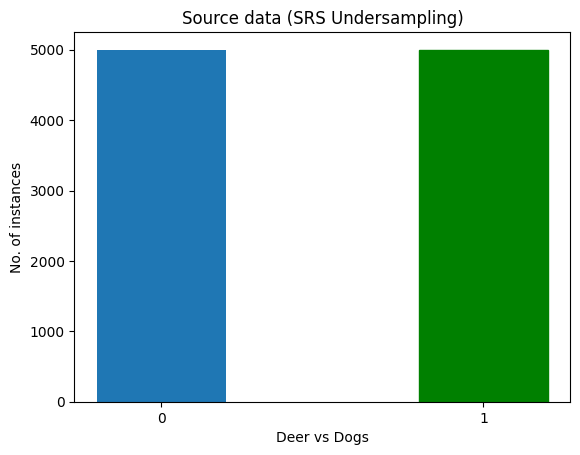

In [ ]:
barlist = plt.bar([str(0),str(1)], y_S_train.value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Dogs")
plt.ylabel("No. of instances")
plt.title("Source data (SRS Undersampling)")
plt.show()

In [ ]:
y_T_train_SRS.value_counts()

,count
Y,
0,5000
1,5000


In [ ]:
y_S_test.value_counts()

,count
Y,
0,3000
1,1000


In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']


# fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8371 - loss: 0.4650 - val_AUC: 0.0000e+00 - val_loss: 0.7836
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8415 - loss: 0.4464 - val_AUC: 0.0000e+00 - val_loss: 0.6888
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - AUC: 0.8415 - loss: 0.4549 - val_AUC: 0.0000e+00 - val_loss: 0.6629
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8485 - loss: 0.4446 - val_AUC: 0.0000e+00 - val_loss: 0.5854
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8495 - loss: 0.4428 - val_AUC: 0.0000e+00 - val_loss: 0.7127
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8523 - loss: 0.4453 - val_AUC: 0.0000e+00 - val_loss: 0.6304
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8414 - loss: 0.4522 - val_AUC: 0.0000e+00 - val_loss: 0.6694
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8497 - loss: 0.4429 - val_AUC: 0.0000e+00 - val_loss: 0.6402
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_SRS_Fine_Tuning.csv')

      FPR    FNR
0   0.324  0.506
1   0.314  0.504
2   0.292  0.522
3   0.360  0.488
4   0.345  0.484
..    ...    ...
95  0.283  0.520
96  0.285  0.512
97  0.301  0.488
98  0.281  0.522
99  0.292  0.502

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.5025200000000001
StDev:  0.02252472491115558


## Simple Random Sampling with Replacement:

In [ ]:
X_S_train, y_S_train = SRSwR_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRSwR_undersampler(data_source_test, data_source_test['Y'])
X_T_train_SRSwR, y_T_train_SRSwR = SRSwR_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRSwR)

5000
15000
5000
15000
13079    0
22539    0
1554     0
15430    0
9749     0
        ..
23976    1
23977    1
23978    1
23981    1
23990    1
Name: Y, Length: 10000, dtype: int64


In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRSwR = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRSwR, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRSwR, X_T_test, y_T_train_SRSwR, y_T_test, 0, 4)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_SRSwR, X_T_test, y_T_train_SRSwR, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_770 (Dense)               │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_771 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_772 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_773 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_774 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_775 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_776 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8747 - loss: 0.4153 - val_AUC: 0.0000e+00 - val_loss: 0.5975
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8706 - loss: 0.4212 - val_AUC: 0.0000e+00 - val_loss: 0.6533
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8692 - loss: 0.4182 - val_AUC: 0.0000e+00 - val_loss: 0.6860
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8730 - loss: 0.4145 - val_AUC: 0.0000e+00 - val_loss: 0.6659
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - AUC: 0.8618 - loss: 0.4285 - val_AUC: 0.0000e+00 - val_loss: 0.6829
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8631 - loss: 0.4328 - val_AUC: 0.0000e+00 - val_loss: 0.6885
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8702 - loss: 0.4164 - val_AUC: 0.0000e+00 - val_loss: 0.6544
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8664 - loss: 0.4214 - val_AUC: 0.0000e+00 - val_loss: 0.6873
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_SRSwR_Fine_Tuning.csv')

      FPR    FNR
0   0.379  0.502
1   0.379  0.504
2   0.362  0.516
3   0.355  0.526
4   0.360  0.516
..    ...    ...
95  0.365  0.500
96  0.329  0.536
97  0.351  0.524
98  0.363  0.512
99  0.367  0.510

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.50562
StDev:  0.020470614563467823


## Systematic Sampling:

First, we select a single systematic sample from the majority class, in which $k = \frac{N_0}{N_1}$, where $N_0$ is the majority class size in the source domain and $N_1$ is the minority class in the source domain.

In [ ]:
X_S_train, y_S_train = systematic_undersampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = systematic_undersampler(data_source_test, data_source_test['Y'])
X_T_train_Sy, y_T_train_Sy = systematic_undersampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
3.0
2
[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49, 52, 55, 58, 61, 64, 67, 70, 73, 76, 79, 82, 85, 88, 91, 94, 97, 100, 103, 106, 109, 112, 115, 118, 121, 124, 127, 130, 133, 136, 139, 142, 145, 148, 151, 154, 157, 160, 163, 166, 169, 172, 175, 178, 181, 184, 187, 190, 193, 196, 199, 202, 205, 208, 211, 214, 217, 220, 223, 226, 229, 232, 235, 238, 241, 244, 247, 250, 253, 256, 259, 262, 265, 268, 271, 274, 277, 280, 283, 286, 289, 292, 295, 298, 301, 304, 307, 310, 313, 316, 319, 322, 325, 328, 331, 334, 337, 340, 343, 346, 349, 352, 355, 358, 361, 364, 367, 370, 373, 376, 379, 382, 385, 388, 391, 394, 397, 400, 403, 406, 409, 412, 415, 418, 421, 424, 427, 430, 433, 436, 439, 442, 445, 448, 451, 454, 457, 460, 463, 466, 469, 472, 475, 478, 481, 484, 487, 490, 493, 496, 499, 502, 505, 508, 511, 514, 517, 520, 523, 526, 529, 532, 535, 538, 541, 544, 547, 550, 553, 556, 559, 562, 565, 568, 571, 574, 577, 580, 583, 586, 589, 592, 595, 598, 601, 604, 607, 610

In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 10
times_fine_tune = 10


FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']


# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_220"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1540 (Dense)              │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1541 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1542 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1543 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1544 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1545 (Dense)              │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1546 (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8528 - loss: 0.4357 - val_AUC: 0.0000e+00 - val_loss: 0.6107
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8630 - loss: 0.4307 - val_AUC: 0.0000e+00 - val_loss: 0.7118
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8668 - loss: 0.4240 - val_AUC: 0.0000e+00 - val_loss: 0.6670
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - AUC: 0.8725 - loss: 0.4193 - val_AUC: 0.0000e+00 - val_loss: 0.7557
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8691 - loss: 0.4174 - val_AUC: 0.0000e+00 - val_loss: 0.6717
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8604 - loss: 0.4330 - val_AUC: 0.0000e+00 - val_loss: 0.6145
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8744 - loss: 0.4119 - val_AUC: 0.0000e+00 - val_loss: 0.6822
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8743 - loss: 0.4108 - val_AUC: 0.0000e+00 - val_loss: 0.5732
Epoch 9/10
250/250 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_Fine_Tuning.csv')

      FPR    FNR
0   0.321  0.550
1   0.330  0.540
2   0.284  0.594
3   0.330  0.540
4   0.359  0.512
..    ...    ...
95  0.298  0.538
96  0.315  0.506
97  0.335  0.494
98  0.297  0.528
99  0.313  0.520

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.5182800000000001
StDev:  0.02351018691735328


## Systematic Sampling (multiple samples):

Now, we investigate the possibility of conducting $m$ systematic samples, each with a sampling interval of $k=m*\frac{N_0}{N_1}$, and obtaining the undersampled majority class data using all $m$ systematic samples combined. This may more closely approximate SRS sampling.


In [ ]:
X_S_train, y_S_train = multi_systematic_undersampler(data_source_train, data_source_train['Y'],5)
# X_S_test, y_S_test = multi_systematic_undersampler(data_source_test, data_source_test['Y'],10)
X_T_train_Sy, y_T_train_Sy = multi_systematic_undersampler(data_source_train, data_source_train['Y'],5)
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
3.0
[9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489, 492, 495, 498, 501, 504, 507, 510, 513, 516, 519, 522, 525, 528, 531, 534, 537, 540, 543, 546, 549, 552, 555, 558, 561, 564, 567, 570, 573, 576, 579, 582, 585, 588, 591, 594, 597, 600, 603, 606, 609, 612, 615, 6

In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (10000, 3072)
y_S_train: (10000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
y_S_test.value_counts()

,count
Y,
0,3000
1,1000


In [ ]:
times_train = 10
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - AUC: 0.8745 - loss: 0.4144 - val_AUC: 0.0000e+00 - val_loss: 0.6326
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8811 - loss: 0.4010 - val_AUC: 0.0000e+00 - val_loss: 0.7767
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.8715 - loss: 0.4114 - val_AUC: 0.0000e+00 - val_loss: 0.6571
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.8730 - loss: 0.4132 - val_AUC: 0.0000e+00 - val_loss: 0.6839
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8743 - loss: 0.4112 - val_AUC: 0.0000e+00 - val_loss: 0.6680
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8829 - loss: 0.3942 - val_AUC: 0.0000e+00 - val_loss: 0.5940
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8788 - loss: 0.3984 - val_AUC: 0.0000e+00 - val_loss: 0.7215
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8653 - loss: 0.4140 - val_AUC: 0.0000e+00 - val_loss: 0.6758
Epoch 9/10
250/250 ━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_multi_Fine_Tuning.csv')

      FPR    FNR
0   0.337  0.522
1   0.335  0.518
2   0.341  0.522
3   0.349  0.508
4   0.336  0.522
..    ...    ...
95  0.332  0.546
96  0.321  0.562
97  0.416  0.464
98  0.381  0.490
99  0.343  0.534

[100 rows x 2 columns]


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.51154
StDev:  0.02500562360992448


# Random Oversampling (ROS):

## Simple Random Sampling with Replacement:

In this case, we investigate the effectiveness of Random Oversampling methods, beginning with Simple Random Sampling (SRS) with replacement. For this, we perform random resampling from the minority class of size $N_1$ to generate an additional sample of size $N_0-N_1$, such that the oversampled minority class will have the same size as the majority class.

In [ ]:
X_S_train, y_S_train = SRSwR_oversampler(data_source_train, data_source_train['Y'])
# X_S_test, y_S_test = SRSwR_oversampler(data_source_test, data_source_test['Y'])
X_T_train_SRS, y_T_train_SRS = SRSwR_oversampler(data_source_train, data_source_train['Y'])
# print(y_S_SRS)

print(y_T_train_SRS)

5000
15000
5000
15000
1        0
2        0
4        0
6        0
7        0
        ..
22262    1
14059    1
21698    1
3388     1
7191     1
Name: Y, Length: 30000, dtype: int64


In [ ]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (30000, 3072)
y_S_train: (30000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [ ]:
times_train = 5
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_SRS_ROS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_SRS_ROS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)
    # print(output)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_SRS, X_T_test, y_T_train_SRS, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_427 (Dense)               │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_428 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_429 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_430 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_431 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_432 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_433 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.9083 - loss: 0.3642 - val_AUC: 0.0000e+00 - val_loss: 0.5286
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9095 - loss: 0.3605 - val_AUC: 0.0000e+00 - val_loss: 0.5532
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.9102 - loss: 0.3595 - val_AUC: 0.0000e+00 - val_loss: 0.5553
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9113 - loss: 0.3559 - val_AUC: 0.0000e+00 - val_loss: 0.5566
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.9062 - loss: 0.3660 - val_AUC: 0.0000e+00 - val_loss: 0.5803
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.9144 - loss: 0.3495 - val_AUC: 0.0000e+00 - val_loss: 0.5513
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9125 - loss: 0.3520 - val_AUC: 0.0000e+00 - val_loss: 0.5627
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9134 - loss: 0.3532 - val_AUC: 0.0000e+00 - val_loss: 0.5325
Epoch 9/10
750/750 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_SRS_ROS_Fine_Tuning.csv')

      FPR    FNR
0   0.374  0.488
1   0.372  0.486
2   0.352  0.512
3   0.345  0.526
4   0.344  0.526
5   0.355  0.522
6   0.353  0.510
7   0.346  0.520
8   0.351  0.526
9   0.344  0.526
10  0.431  0.436
11  0.425  0.458
12  0.422  0.446
13  0.404  0.462
14  0.409  0.462
15  0.442  0.436
16  0.412  0.458
17  0.413  0.478
18  0.409  0.466
19  0.417  0.464
20  0.414  0.438
21  0.353  0.502
22  0.384  0.482
23  0.377  0.470
24  0.401  0.456
25  0.376  0.488
26  0.363  0.498
27  0.393  0.458
28  0.366  0.488
29  0.375  0.486
30  0.396  0.494
31  0.399  0.500
32  0.367  0.522
33  0.382  0.514
34  0.384  0.504
35  0.411  0.470
36  0.412  0.490
37  0.367  0.518
38  0.391  0.492
39  0.371  0.528
40  0.383  0.480
41  0.379  0.482
42  0.386  0.482
43  0.377  0.486
44  0.400  0.466
45  0.376  0.502
46  0.381  0.486
47  0.362  0.516
48  0.389  0.478
49  0.395  0.456


In [ ]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.4868
StDev:  0.026092457272756286


## Systematic Resampling:

In this case, we examine the possibility of performing Random Oversampling on the minority class using systematic sampling. For this purpose, taking a sampling interval of $k$, we would compile a total of $k*\frac{N_0-N_1}{N_1}$ systematic samples from the minority class in order to balance the dataset. We sample the starting point from 1 to $k$ *with replacement*, since a highly imbalanced dataset will require sampling with replacement in order to achieve a balanced dataset.

Here, we take $k=10$ for the source training data and $k=20$ for the target training data.


In [38]:
X_S_train, y_S_train = systematic_resampler(data_source_train, data_source_train['Y'], 10)
# X_S_test, y_S_test = systematic_resampler(data_source_test, data_source_test['Y'], 10)
X_T_train_Sy, y_T_train_Sy = systematic_resampler(data_source_train, data_source_train['Y'], 20)
# print(y_S_SRS)

print(y_T_train_Sy)

5000
15000
Nsamples= 20.0
5000
15000
Nsamples= 40.0
1        0
2        0
4        0
6        0
7        0
        ..
23511    1
23596    1
23734    1
23816    1
23932    1
Name: Y, Length: 30000, dtype: int64


In [39]:
print('X_S_train:',np.shape(X_S_train))
print('y_S_train:',np.shape(y_S_train))
print('X_S_test:',np.shape(X_S_test))
print('y_S_test:',np.shape(y_S_test))

X_S_train: (30000, 3072)
y_S_train: (30000,)
X_S_test: (4000, 3072)
y_S_test: (4000,)


In [40]:
times_train = 5
times_fine_tune = 10

FPR = []
FNR = []

for i in range(times_train):
  model_source_Sy_ROS = create_dnn_model(X_S_train.shape[1])
  train_and_evaluate(model_source_Sy_ROS, X_S_train, X_S_test, y_S_train, y_S_test, "Source")
  for j in range(times_fine_tune):
    fpr, fnr = fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)
    FPR.append(fpr)
    FNR.append(fnr)

ParamFit = pd.DataFrame([FPR, FNR]).T
ParamFit.columns=['FPR', 'FNR']

# fine_tuning(X_T_train_Sy, X_T_test, y_T_train_Sy, y_T_test, 0, 4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,009 (793.00 KB)

 Trainable params: 203,009 (793.00 KB)

...

 Trainable params: 203,009 (793.00 KB)

 Non-trainable params: 0 (0.00 B)

7
Not Trainable
Not Trainable
Not Trainable
Not Trainable
Trainable
Trainable
Not Trainable


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.9057 - loss: 0.3672 - val_AUC: 0.0000e+00 - val_loss: 0.5505
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9056 - loss: 0.3669 - val_AUC: 0.0000e+00 - val_loss: 0.5277
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9067 - loss: 0.3657 - val_AUC: 0.0000e+00 - val_loss: 0.5336
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.9047 - loss: 0.3675 - val_AUC: 0.0000e+00 - val_loss: 0.5210
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.9095 - loss: 0.3595 - val_AUC: 0.0000e+00 - val_loss: 0.5157
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.9049 - loss: 0.3688 - val_AUC: 0.0000e+00 - val_loss: 0.5339
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.9090 - loss: 0.3588 - val_AUC: 0.0000e+00 - val_loss: 0.5110
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.9075 - loss: 0.3641 - val_AUC: 0.0000e+00 - val_loss: 0.5129
Epoch 9/10
750/750 ━━━━━

In [41]:
print(ParamFit)
ParamFit.to_csv('CIFAR_Sy_ROS_Fine_Tuning.csv')

      FPR    FNR
0   0.347  0.540
1   0.348  0.534
2   0.370  0.516
3   0.387  0.502
4   0.391  0.500
5   0.372  0.520
6   0.373  0.514
7   0.383  0.516
8   0.375  0.516
9   0.378  0.520
10  0.393  0.486
11  0.368  0.514
12  0.394  0.496
13  0.364  0.508
14  0.389  0.498
15  0.379  0.498
16  0.355  0.534
17  0.400  0.482
18  0.361  0.524
19  0.402  0.498
20  0.399  0.496
21  0.376  0.514
22  0.414  0.490
23  0.385  0.504
24  0.380  0.510
25  0.388  0.506
26  0.378  0.504
27  0.405  0.492
28  0.371  0.520
29  0.380  0.502
30  0.328  0.568
31  0.321  0.560
32  0.351  0.530
33  0.349  0.534
34  0.338  0.532
35  0.358  0.526
36  0.382  0.506
37  0.353  0.532
38  0.362  0.522
39  0.373  0.506
40  0.403  0.488
41  0.388  0.508
42  0.370  0.524
43  0.382  0.510
44  0.370  0.522
45  0.377  0.510
46  0.402  0.492
47  0.388  0.510
48  0.368  0.526
49  0.368  0.506


In [42]:
print('Mean: ', ParamFit['FNR'].mean())
print('StDev: ', ParamFit['FNR'].std())

Mean:  0.51332
StDev:  0.01752251030380462
